Note: you may need to restart the kernel to use updated packages.
                          Metric      Hilton Food Group plc (HFG)  \
0                         Ticker                            HFG.L   
1  Share price (7 Oct 2026, GBp)                              708   
2          Market capitalisation        Approx. GBP 631.5m-643.2m   
3                 Dividend yield                Approx. 4.9%-5.5%   
4        Latest full-year period  FY2025, 52 weeks to 28 Dec 2025   

                                 Cranswick plc (CWK)  \
0                                              CWK.L   
1                                               4970   
2  Not consistently sourced; materially larger th...   
3                     Not directly sourced in report   
4                    FY2026, 52 weeks to 28 Mar 2026   

                                     Notes  
0                    London Stock Exchange  
1                   Reported market prices  
2  HFG market cap from market-data sources  
3 

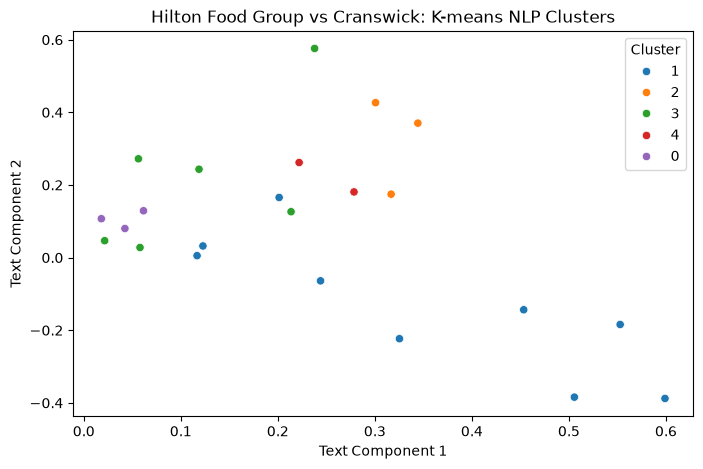

Analysis complete. Results saved to CSV.


In [1]:
# 1. Import libraries
%pip install -q pandas numpy matplotlib scikit-learn seaborn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

# 2. Load dataset
df = pd.read_csv("Hilton_Food_Group_vs_Cranswick_Comparison.csv")
df.drop_duplicates(inplace=True)
print(df.head())
print(df.columns.tolist())

# 3. Automatically identify text columns
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

if not text_cols:
    raise ValueError("No text columns found. Check your CSV.")

df["Text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 4. Clean text using NLP
def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return " ".join(
        word for word in text.split()
        if word not in ENGLISH_STOP_WORDS and len(word) > 2
    )

df["Clean_Text"] = df["Text"].apply(clean_text)

# 5. Convert text into TF-IDF features
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X = tfidf.fit_transform(df["Clean_Text"])

# 6. Find the best number of clusters
if len(df) < 3 or X.shape[1] < 2:
    raise ValueError("Need at least 3 records and 2 text features.")

scores = {}
for k in range(2, min(6, len(df))):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)
print("Best clusters:", best_k)
print("Silhouette scores:", scores)

# 7. Apply K-means
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 8. Display important words per cluster
terms = np.array(tfidf.get_feature_names_out())

for i, center in enumerate(model.cluster_centers_):
    top_words = terms[center.argsort()[-10:][::-1]]
    print(f"Cluster {i}: {', '.join(top_words)}")

# 9. Visualise clusters
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=df["Cluster"].astype(str), palette="tab10")
plt.title("Hilton Food Group vs Cranswick: K-means NLP Clusters")
plt.xlabel("Text Component 1")
plt.ylabel("Text Component 2")
plt.show()

# 10. Export results
df.to_csv("Hilton_Cranswick_KMeans_NLP_Results.csv", index=False)
print("Analysis complete. Results saved to CSV.")